In [1]:
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path.cwd().parent))
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, Any, List, Tuple, Callable
from collections import Counter
import json
from itertools import product
from dataclasses import dataclass
from enum import Enum

from backtesting import Backtest

from strat.s_orb import build_features as orb_build, convert_to_ohlcv as orb_conv, ORBStrategy
from strat.s_gap_and_go import build_features as gag_build, convert_to_ohlcv as gag_conv, GapAndGoStrategy
from strat.s_vwap_reclaim import build_features as vwap_build, convert_to_ohlcv as vwap_conv, VWAPReclaimStrategy
from strat.s_fade_open import build_features as fade_build, convert_to_ohlcv as fade_conv, FadeOpenStrategy
from strat.s_first5_bias import build_features as f5b_build, convert_to_ohlcv as f5b_conv, First5BiasStrategy
from strat.s_london_momentum import build_features as lon_build, convert_to_ohlcv as lon_conv, LondonMomentumStrategy
from strat.s_gap_fill import build_features as gf_build, convert_to_ohlcv as gf_conv, GapFillStrategy
from strat.s_ema_crossover import build_features as ema_build, convert_to_ohlcv as ema_conv, EMACrossoverStrategy
from strat.s_macd_crossover import build_features as macd_build, convert_to_ohlcv as macd_conv, MACDCrossoverStrategy
from strat.s_rsi_mean_reversion import build_features as rsi_build, convert_to_ohlcv as rsi_conv, RSIMeanReversionStrategy
from strat.s_bb_squeeze import build_features as bb_build, convert_to_ohlcv as bb_conv, BBSqueezeStrategy
from strat.s_donchian_breakout import build_features as dc_build, convert_to_ohlcv as dc_conv, DonchianBreakoutStrategy

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('Setup complete!')

Loading BokehJS ...

Setup complete!


In [2]:
class OptimMetric(Enum):
    SHARPE = "sharpe_ratio"
    CALMAR = "calmar_ratio"
    TOTAL_RETURN = "total_return"
    PROFIT_FACTOR = "profit_factor"

@dataclass
class OptimResult:
    params: Dict[str, Any]
    metrics: Dict[str, float]
    sharpe: float
    calmar: float
    total_return: float
    profit_factor: float
    max_drawdown: float
    win_rate: float
    n_trades: int

def grid_search(
    func: Callable[[pd.DataFrame, Dict[str, Any]], Dict[str, float]],
    df: pd.DataFrame,
    param_ranges: Dict[str, List[Any]],
    optim_metric: OptimMetric = OptimMetric.SHARPE,
    maximize: bool = True,
    verbose: bool = True,
) -> Tuple[pd.DataFrame, OptimResult, pd.DataFrame]:
    param_names = list(param_ranges.keys())
    param_values = list(param_ranges.values())
    combinations = list(product(*param_values))
    total = len(combinations)
    
    if verbose:
        print(f'Running grid search with {total} combinations...')
    
    results = []
    for i, combo in enumerate(combinations):
        params = dict(zip(param_names, combo))
        try:
            metrics = func(df.copy(), params)
            results.append({
                **params,
                'sharpe_ratio': metrics.get('sharpe_ratio', np.nan),
                'calmar_ratio': metrics.get('calmar_ratio', np.nan),
                'total_return': metrics.get('total_return', np.nan),
                'profit_factor': metrics.get('profit_factor', np.nan),
                'max_drawdown': metrics.get('max_drawdown', np.nan),
                'win_rate': metrics.get('win_rate', np.nan),
                'n_trades': metrics.get('n_trades', np.nan),
                'error': None,
            })
        except Exception as e:
            results.append({
                **{k: v for k, v in params.items()},
                'sharpe_ratio': np.nan, 'calmar_ratio': np.nan,
                'total_return': np.nan, 'profit_factor': np.nan,
                'max_drawdown': np.nan, 'win_rate': np.nan, 'n_trades': np.nan,
                'error': str(e),
            })
    
    results_df = pd.DataFrame(results)
    results_df = results_df.dropna(subset=[optim_metric.value])
    
    if len(results_df) == 0:
        raise ValueError('No valid results')
    
    best_idx = results_df[optim_metric.value].idxmax() if maximize else results_df[optim_metric.value].idxmin()
    best_row = results_df.loc[best_idx]
    
    best_result = OptimResult(
        params={k: best_row[k] for k in param_names},
        metrics={},
        sharpe=best_row['sharpe_ratio'],
        calmar=best_row['calmar_ratio'],
        total_return=best_row['total_return'],
        profit_factor=best_row['profit_factor'],
        max_drawdown=best_row['max_drawdown'],
        win_rate=best_row['win_rate'],
        n_trades=int(best_row['n_trades']),
    )
    
    return results_df, best_result, pd.DataFrame()

print('Grid search ready!')

Grid search ready!


In [3]:
STRATEGY_REGISTRY = {
    'orb': {'name': 'ORB', 'build': orb_build, 'convert': orb_conv, 'strategy': ORBStrategy,
        'default': {'p_or_candles': 1, 'p_vol_filter': True, 'p_direction': 'both'},
        'optim': {'p_or_candles': [1, 2, 3], 'p_vol_filter': [True, False], 'atr_mult': [1.0, 1.5, 2.0, 3.0], 'rr': [1.0, 1.5, 2.0, 3.0]}},

    'gap_and_go': {'name': 'Gap & Go', 'build': gag_build, 'convert': gag_conv, 'strategy': GapAndGoStrategy,
               'default': {'p_min_gap_pct': 0.30, 'p_vol_mult': 1.50, 'p_direction': 'both'},
               'optim': {'p_min_gap_pct': [0.20, 0.30, 0.50, 0.75],
                         'p_vol_mult': [1.2, 1.5, 2.0, 2.5],
                         'atr_mult': [1.0, 1.5, 2.0, 3.0],
                         'rr': [1.0, 1.5, 2.0, 3.0]}},

    'vwap_reclaim': {'name': 'VWAP Reclaim', 'build': vwap_build, 'convert': vwap_conv, 'strategy': VWAPReclaimStrategy,
                 'default': {'p_vol_filter': True, 'p_direction': 'both'},
                 'optim': {'p_vol_filter': [True, False],
                           'p_reclaim_buffer': [0.0, 0.1, 0.2],
                           'atr_mult': [1.0, 1.5, 2.0, 3.0],
                           'rr': [1.0, 1.5, 2.0, 3.0]}},

    'fade_open': {'name': 'Fade Open', 'build': fade_build, 'convert': fade_conv, 'strategy': FadeOpenStrategy,
              'default': {'p_min_gap_pct': 0.75, 'p_direction': 'both'},
              'optim': {'p_min_gap_pct': [0.50, 0.75, 1.0, 1.5],
                        'atr_mult': [1.0, 1.5, 2.0, 3.0],
                        'rr': [1.0, 1.5, 2.0, 3.0]}},

    'first5_bias': {'name': 'First 5 Bias', 'build': f5b_build, 'convert': f5b_conv, 'strategy': First5BiasStrategy,
                'default': {'p_pullback_pct': 0.50, 'p_direction': 'both'},
                'optim': {'p_pullback_pct': [0.30, 0.50, 0.70],
                          'atr_mult': [1.0, 1.5, 2.0, 3.0],
                          'rr': [1.0, 1.5, 2.0, 3.0]}},

    'london_momentum': {'name': 'London Momentum', 'build': lon_build, 'convert': lon_conv, 'strategy': LondonMomentumStrategy,
                    'default': {'p_min_move_pct': 0.30, 'p_vol_mult': 1.30, 'p_direction': 'both'},
                    'optim': {'p_min_move_pct': [0.20, 0.30, 0.50],
                              'p_vol_mult': [1.2, 1.5, 2.0, 2.5],
                              'atr_mult': [1.0, 1.5, 2.0, 3.0],
                              'rr': [1.0, 1.5, 2.0, 3.0]}},

    'gap_fill': {'name': 'Gap Fill', 'build': gf_build, 'convert': gf_conv, 'strategy': GapFillStrategy,
             'default': {'p_min_gap_pct': 0.20, 'p_max_gap_pct': 1.50, 'p_direction': 'both'},
             'optim': {'p_min_gap_pct': [0.10, 0.20, 0.30],
                       'p_max_gap_pct': [1.0, 1.5, 2.0],
                       'atr_mult': [1.0, 1.5, 2.0, 3.0],
                       'rr': [1.0, 1.5, 2.0, 3.0]}},

    'ema_crossover': {'name': 'EMA Crossover', 'build': ema_build, 'convert': ema_conv, 'strategy': EMACrossoverStrategy,
                  'default': {'p_fast_period': 12, 'p_slow_period': 50, 'p_direction': 'both'},
                  'optim': {'p_fast_period': [9, 12, 20, 30, 60, 120],
                            'p_slow_period': [21, 50, 100, 200, 400, 1000, 2000],
                            'atr_mult': [1.0, 1.5, 2.0, 3.0],
                            'rr': [1.0, 1.5, 2.0, 3.0]}},

    'macd_crossover': {'name': 'MACD Crossover', 'build': macd_build, 'convert': macd_conv, 'strategy': MACDCrossoverStrategy,
                   'default': {'p_fast': 12, 'p_slow': 26, 'p_signal': 9, 'p_direction': 'both'},
                   'optim': {'p_fast': [8, 12, 16],
                             'p_slow': [26, 35, 50],
                             'p_signal': [9],
                             'atr_mult': [1.0, 1.5, 2.0, 3.0],
                             'rr': [1.0, 1.5, 2.0, 3.0]}},

    'rsi_mean_reversion': {'name': 'RSI Mean Reversion', 'build': rsi_build, 'convert': rsi_conv, 'strategy': RSIMeanReversionStrategy,
                       'default': {'p_rsi_period': 14, 'p_oversold': 25, 'p_overbought': 75, 'p_direction': 'both'},
                       'optim': {'p_rsi_period': [14, 21, 28],
                                 'p_oversold': [20, 25, 30],
                                 'p_overbought': [70, 75, 80],
                                 'atr_mult': [1.0, 1.5, 2.0, 3.0],
                                 'rr': [1.0, 1.5, 2.0, 3.0]}},

    'bb_squeeze': {'name': 'BB Squeeze', 'build': bb_build, 'convert': bb_conv, 'strategy': BBSqueezeStrategy,
               'default': {'p_bb_period': 20, 'p_direction': 'both'},
               'optim': {'p_bb_period': [20, 30, 50],
                         'atr_mult': [1.0, 1.5, 2.0, 3.0],
                         'rr': [1.0, 1.5, 2.0, 3.0]}},

    'donchian_breakout': {'name': 'Donchian', 'build': dc_build, 'convert': dc_conv, 'strategy': DonchianBreakoutStrategy,
                      'default': {'p_channel_period': 50, 'p_direction': 'both'},
                      'optim': {'p_channel_period': [20, 50, 100],
                                'atr_mult': [1.0, 1.5, 2.0, 3.0],
                                'rr': [1.0, 1.5, 2.0, 3.0]}},
}

print('Available:', list(STRATEGY_REGISTRY.keys()))

Available: ['orb', 'gap_and_go', 'vwap_reclaim', 'fade_open', 'first5_bias', 'london_momentum', 'gap_fill', 'ema_crossover', 'macd_crossover', 'rsi_mean_reversion', 'bb_squeeze', 'donchian_breakout']


In [5]:
# CONFIGURATION
STRATEGY_KEY = 'ema_crossover'
BUNDLE_PATH = Path('/data/bundle/etf_x_ext_list_features_bundle.parquet')
SYMBOL = 'QQQ'
LOOKBACK_BARS = 4400
FORWARD_BARS = 100
STEP_BARS = 500
INITIAL_CASH = 100
COMMISSION = 0.0001

strategy_info = STRATEGY_REGISTRY[STRATEGY_KEY]
print(f'Strategy: {strategy_info["name"]}')
print(f'Bundle: {BUNDLE_PATH}')
print(f'Symbol: {SYMBOL}')

Strategy: EMA Crossover
Bundle: /data/bundle/etf_x_ext_list_features_bundle.parquet
Symbol: QQQ


In [6]:
def load_bundle(p_path: Path, p_symbol: str) -> pd.DataFrame:
    df_bundle = pd.read_parquet(p_path)
    cols = [c for c in df_bundle.columns if c.startswith(f"{p_symbol}_")]
    if not cols:
        raise ValueError(f"No {p_symbol} columns found in bundle")
    col_mapping = {col: col.replace(f"{p_symbol}_", "") for col in cols}
    df = df_bundle[cols].rename(columns=col_mapping).copy()
    if "i_minute_i" in df_bundle.columns:
        df["i_minute_i"] = df_bundle["i_minute_i"]
    return df

df_raw = load_bundle(BUNDLE_PATH, SYMBOL)
base = pd.Timestamp('2000-01-01')
df_raw['datetime'] = base + pd.to_timedelta(df_raw['i_minute_i'], unit='m')
df_raw = df_raw.dropna(subset=['S_open_f32', 'S_high_f32', 'S_low_f32', 'S_close_f32'])
print(f'Loaded {len(df_raw):,} bars: {df_raw["datetime"].iloc[0]} to {df_raw["datetime"].iloc[-1]}')

Loaded 36,874 bars: 2007-01-11 09:00:00 to 2026-02-26 16:00:00


In [7]:
def run_backtest(df, params, strategy_info, initial_cash=100000, commission=0.0002):
    try:
        build_params = {k: v for k, v in params.items() if not k.startswith('atr') and not k.startswith('rr')}
        bt_params = {k: v for k, v in params.items() if k.startswith('atr') or k.startswith('rr')}
        bt_params.setdefault('direction', 'both')
        bt_params.setdefault('atr_mult', 2.0)
        bt_params.setdefault('rr', 2.0)
        
        df_feat = strategy_info['build'](df.copy(), **build_params)
        ohlcv = strategy_info['convert'](df_feat)
        
        bt = Backtest(ohlcv, strategy_info.get('strategy') or ORBStrategy,
                      cash=initial_cash, commission=commission, trade_on_close=True)
        result = bt.run(**bt_params)
        
        return {
            'sharpe_ratio': result['Sharpe Ratio'] if pd.notna(result['Sharpe Ratio']) else 0,
            'total_return': result['Return [%]'] if pd.notna(result['Return [%]']) else 0,
            'max_drawdown': result['Max. Drawdown [%]'] if pd.notna(result['Max. Drawdown [%]']) else 0,
            'win_rate': result['Win Rate [%]'] if pd.notna(result['Win Rate [%]']) else 0,
            'n_trades': result['# Trades'] if pd.notna(result['# Trades']) else 0,
            'profit_factor': result['Profit Factor'] if pd.notna(result['Profit Factor']) else 0,
            'calmar_ratio': result['Calmar Ratio'] if pd.notna(result['Calmar Ratio']) else 0,
        }
    except Exception as e:
        return {'sharpe_ratio': -999, 'total_return': -999, 'max_drawdown': 100, 'win_rate': 0, 'n_trades': 0, 'profit_factor': 0, 'calmar_ratio': 0}

test_params = {**strategy_info['default'], 'atr_mult': 2.0, 'rr': 2.0}
test = run_backtest(df_raw.head(1000), test_params, strategy_info)
print('Test:', test)

Backtest.run:   0%|          | 0/986 [00:00<?, ?bar/s]

Test: {'sharpe_ratio': -0.5731599947067466, 'total_return': -2.9927890625, 'max_drawdown': -10.383961926113516, 'win_rate': 26.666666666666668, 'n_trades': 15, 'profit_factor': 0.7830369472503662, 'calmar_ratio': -0.47616033110480116}


In [ ]:
n_bars = len(df_raw)
start_idx = LOOKBACK_BARS
param_ranges = strategy_info['optim']

results = []
best_params_history = []

print(f'Walk-forward: {n_bars} bars, IS={LOOKBACK_BARS}, OOS={FORWARD_BARS}, step={STEP_BARS}')

for window_num, window_start in enumerate(range(start_idx, n_bars - FORWARD_BARS, STEP_BARS), 1):
    is_end = window_start + LOOKBACK_BARS
    oos_start, oos_end = is_end, min(is_end + FORWARD_BARS, n_bars)
    
    df_is = df_raw.iloc[window_start:is_end]
    df_oos = df_raw.iloc[oos_start:oos_end]
    
    def is_func(p_df, p): return run_backtest(p_df, p, strategy_info, INITIAL_CASH, COMMISSION)
    
    _, best, _ = grid_search(is_func, df_is, param_ranges, OptimMetric.SHARPE, verbose=False)
    best_params = best.params
    best_params_history.append({'window': window_num, 'params': best_params, 'is_sharpe': best.sharpe})
    
    oos_metrics = run_backtest(df_oos, best_params, strategy_info, INITIAL_CASH, COMMISSION)
    
    results.append({
        'window': window_num, 'is_start': window_start, 'is_end': is_end,
        'oos_start': oos_start, 'oos_end': oos_end,
        'is_sharpe': best.sharpe, 'is_return': best.total_return,
        'oos_sharpe': oos_metrics['sharpe_ratio'], 'oos_return': oos_metrics['total_return'],
        'oos_max_dd': oos_metrics['max_drawdown'], 'oos_n_trades': oos_metrics['n_trades'],
        **best_params
    })
    print(f'W{window_num}: IS={best.sharpe:.2f}, OOS={oos_metrics["sharpe_ratio"]:.2f}')

results_df = pd.DataFrame(results)
summary = {
    'n_windows': len(results),
    'avg_oos_sharpe': results_df['oos_sharpe'].mean(),
    'avg_oos_return': results_df['oos_return'].mean(),
    'avg_oos_max_dd': results_df['oos_max_dd'].mean(),
}
print(f'\nSummary: Avg OOS Sharpe={summary["avg_oos_sharpe"]:.2f}')

Walk-forward: 36874 bars, IS=4400, OOS=100, step=500


Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/86 [00:00<?, ?bar/s]

W1: IS=1.98, OOS=0.00


Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/86 [00:00<?, ?bar/s]

W2: IS=1.72, OOS=0.00


Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/86 [00:00<?, ?bar/s]

W3: IS=1.74, OOS=-6.48


Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/86 [00:00<?, ?bar/s]

W4: IS=1.75, OOS=5.97


Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/86 [00:00<?, ?bar/s]

W5: IS=1.73, OOS=0.00


Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/86 [00:00<?, ?bar/s]

W6: IS=1.53, OOS=3.14


Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/86 [00:00<?, ?bar/s]

W7: IS=1.66, OOS=2.70


Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/86 [00:00<?, ?bar/s]

W8: IS=1.31, OOS=-3.91


Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/86 [00:00<?, ?bar/s]

W9: IS=1.49, OOS=5.97


Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

Backtest.run:   0%|          | 0/4386 [00:00<?, ?bar/s]

In [31]:
param_names = list(param_ranges.keys())
stability = {}

for param in param_names:
    values = [h['params'].get(param) for h in best_params_history]
    counter = Counter(values)
    most_common = counter.most_common(1)[0] if counter else (None, 0)
    stability[param] = {'most_common': most_common[0], 'consistency': most_common[1]/len(best_params_history), 'all_values': dict(counter)}

print('PARAMETER ROBUSTNESS:')
for param, stats in sorted(stability.items(), key=lambda x: -x[1]['consistency']):
    print(f'  {param}: {stats["most_common"]} ({stats["consistency"]*100:.0f}%)')

final_params = {param: stats['most_common'] for param, stats in stability.items() if stats['consistency'] >= 0.3}
print(f'\nRecommended: {final_params}')

PARAMETER ROBUSTNESS:
  p_rsi_period: 7 (100%)
  p_oversold: 25 (100%)
  atr_mult: 1.5 (100%)
  rr: 1.5 (100%)

Recommended: {'p_rsi_period': np.int64(7), 'p_oversold': np.int64(25), 'atr_mult': np.float64(1.5), 'rr': np.float64(1.5)}


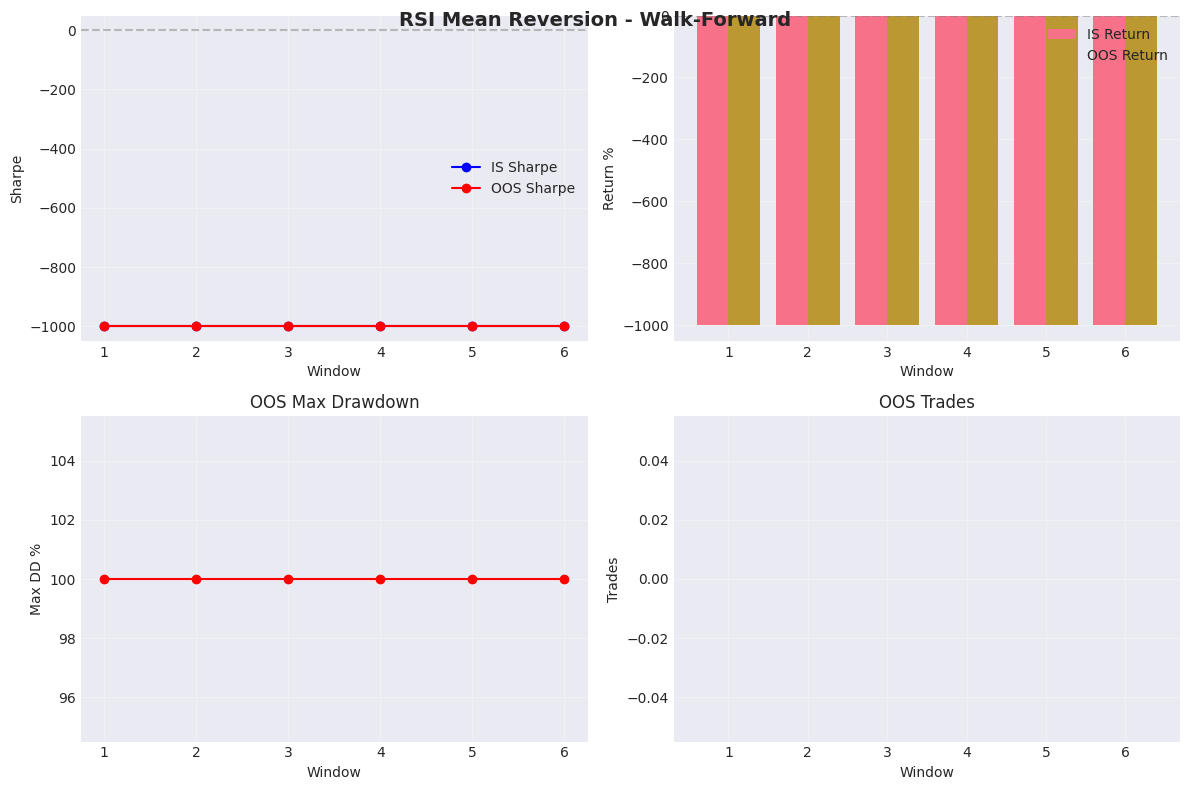

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

ax1 = axes[0, 0]
ax1.plot(results_df['window'], results_df['is_sharpe'], 'b-o', label='IS Sharpe')
ax1.plot(results_df['window'], results_df['oos_sharpe'], 'r-o', label='OOS Sharpe')
ax1.axhline(0, color='gray', ls='--', alpha=0.5)
ax1.set_xlabel('Window'); ax1.set_ylabel('Sharpe'); ax1.legend(); ax1.grid(alpha=0.3)

ax2 = axes[0, 1]
ax2.bar(results_df['window']-0.2, results_df['is_return'], 0.4, label='IS Return')
ax2.bar(results_df['window']+0.2, results_df['oos_return'], 0.4, label='OOS Return')
ax2.axhline(0, color='gray', ls='--', alpha=0.5)
ax2.set_xlabel('Window'); ax2.set_ylabel('Return %'); ax2.legend(); ax2.grid(alpha=0.3)

ax3 = axes[1, 0]
ax3.plot(results_df['window'], results_df['oos_max_dd'], 'r-o')
ax3.set_xlabel('Window'); ax3.set_ylabel('Max DD %'); ax3.set_title('OOS Max Drawdown'); ax3.grid(alpha=0.3)

ax4 = axes[1, 1]
ax4.bar(results_df['window'], results_df['oos_n_trades'], color='green')
ax4.set_xlabel('Window'); ax4.set_ylabel('Trades'); ax4.set_title('OOS Trades'); ax4.grid(alpha=0.3)

plt.tight_layout()
plt.suptitle(f"{strategy_info['name']} - Walk-Forward", fontsize=14, fontweight='bold')
plt.show()

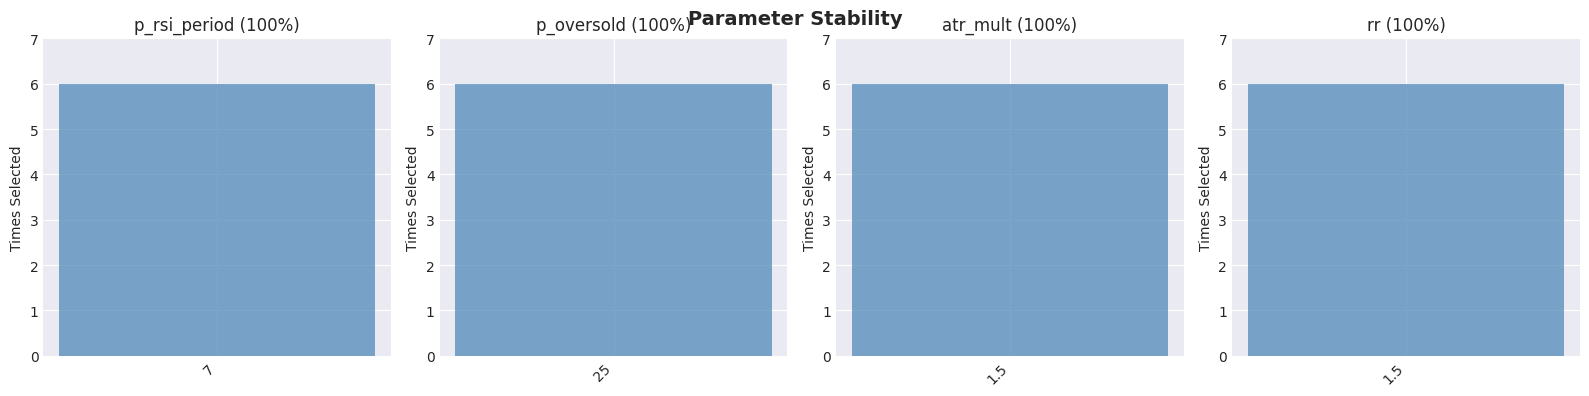

In [33]:
fig, axes = plt.subplots(1, len(param_names), figsize=(4*len(param_names), 4))
if len(param_names) == 1: axes = [axes]

for idx, param in enumerate(param_names):
    ax = axes[idx]
    stats = stability[param]
    values = list(stats['all_values'].keys())
    counts = list(stats['all_values'].values())
    ax.bar(range(len(values)), counts, color='steelblue', alpha=0.7)
    ax.set_xticks(range(len(values)))
    ax.set_xticklabels(values, rotation=45, ha='right')
    ax.set_ylabel('Times Selected')
    ax.set_title(f'{param} ({stats["consistency"]*100:.0f}%)')
    ax.set_ylim(0, len(best_params_history) + 1)

plt.tight_layout()
plt.suptitle('Parameter Stability', fontsize=14, fontweight='bold')
plt.show()

In [34]:
Path('results').mkdir(exist_ok=True)
output = {
    'strategy': STRATEGY_KEY,
    'strategy_name': strategy_info['name'],
    'bundle_path': str(BUNDLE_PATH),
    'symbol': SYMBOL,
    'n_windows': len(results),
    'summary': summary,
    'recommended_params': final_params,
}
with open(f'results/{STRATEGY_KEY}_walkforward.json', 'w') as f:
    json.dump(output, f, indent=2, default=str)

print(f'Saved: results/{STRATEGY_KEY}_walkforward.json')
print(f'Summary: Sharpe={summary["avg_oos_sharpe"]:.2f}, Return={summary["avg_oos_return"]:.1f}%')

Saved: results/rsi_mean_reversion_walkforward.json
Summary: Sharpe=-999.00, Return=-999.0%
